# Analisis Dataset WorldCup98 (Granularitas Detik)
Notebook ini memproses file log akses biner **WorldCup98 (TR2)**, melakukan decoding terhadap kolom bitwise, melakukan pemetaan rute ke microservices virtual, serta menghitung **Requests Per Second (RPS)** tingkat detik.

Trafik WorldCup98 terkenal sangat fluktuatif dan dinamis, menjadikannya benchmark ideal untuk pengujian proaktif auto-scaling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import struct
import time
from datetime import datetime

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12


In [2]:
log_file_path = 'dataset/TR2'

print("Membaca dan mem-parsing file log biner WorldCup98...")
start_time = time.time()

# Struktur C: 4 uint32 (I) + 4 uint8 (B) = 20 byte
record_struct = struct.Struct('>IIIIBBBB')

# Baca seluruh file biner ke memory untuk kecepatan maksimum
with open(log_file_path, 'rb') as f:
    binary_data = f.read()

total_records = len(binary_data) // 20
print(f"Total entri dalam log biner: {total_records}")

# Gunakan unpack_from untuk iterasi berkecepatan tinggi tanpa membuat jutaan objek tuple perantara
timestamps = np.zeros(total_records, dtype=np.uint32)
client_ids = np.zeros(total_records, dtype=np.uint32)
object_ids = np.zeros(total_records, dtype=np.uint32)
sizes = np.zeros(total_records, dtype=np.uint32)
methods = np.zeros(total_records, dtype=np.uint8)
statuses = np.zeros(total_records, dtype=np.uint8)
filetypes = np.zeros(total_records, dtype=np.uint8)
servers = np.zeros(total_records, dtype=np.uint8)

offset = 0
for i in range(total_records):
    ts, cid, oid, sz, meth, stat, ftype, srv = record_struct.unpack_from(binary_data, offset)
    timestamps[i] = ts
    client_ids[i] = cid
    object_ids[i] = oid
    sizes[i] = sz
    methods[i] = meth
    statuses[i] = stat
    filetypes[i] = ftype
    servers[i] = srv
    offset += 20

# Buat DataFrame pandas dari numpy arrays langsung
df = pd.DataFrame({
    'timestamp': timestamps,
    'method_code': methods,
    'status_code': statuses,
    'filetype_code': filetypes,
    'server_code': servers,
    'size_bytes': sizes
})

print(f"Selesai mem-parsing {len(df)} baris dalam {time.time() - start_time:.2f} detik")
df.head()


Membaca dan mem-parsing file log biner WorldCup98...
Total entri dalam log biner: 1262614


Selesai mem-parsing 1262614 baris dalam 2.85 detik


,timestamp,method_code,status_code,filetype_code,server_code,size_bytes
0,894232802,0,66,1,32,1379
1,894232802,0,66,1,32,118
2,894232802,0,66,1,32,248
3,894232803,0,77,10,32,0
4,894232803,0,66,1,32,163


In [3]:
# 1. Konversi waktu (GMT+2 untuk waktu Prancis saat World Cup 98)
df['datetime'] = pd.to_datetime(df['timestamp'] + 7200, unit='s')
df.set_index('datetime', inplace=True)
df.sort_index(inplace=True)

# 2. Decode http_status (6 bit terbawah dari status_code)
df['http_status'] = np.bitwise_and(df['status_code'], 0x3F)

# 3. Decode server region (3 bit teratas dari server_code)
df['region_code'] = np.right_shift(df['server_code'], 5)

# Map ke string kategori menggunakan kamus pemetaan resmi
method_map = {0: 'GET', 1: 'HEAD', 2: 'POST', 3: 'PUT', 4: 'DELETE', 6: 'OPTIONS'}
filetype_map = {0: 'HTML', 1: 'IMAGE', 2: 'AUDIO', 3: 'VIDEO', 4: 'JAVA', 5: 'FORMATTED', 6: 'DYNAMIC', 7: 'TEXT', 8: 'COMPRESSED', 9: 'PROGRAMS', 10: 'DIRECTORY', 11: 'ICCL', 12: 'OTHER'}
region_map = {0: 'SANTA_CLARA', 1: 'PLANO', 2: 'HERNDON', 3: 'PARIS'}
status_map = {2: '200', 13: '304', 19: '404', 18: '403', 31: '500'}

df['method'] = df['method_code'].map(method_map).fillna('OTHER').astype('category')
df['filetype'] = df['filetype_code'].map(filetype_map).fillna('OTHER').astype('category')
df['region'] = df['region_code'].map(region_map).fillna('OTHER').astype('category')
df['status'] = df['http_status'].map(status_map).fillna('OTHER').astype('category')

# Hapus kolom mentah biner yang tidak digunakan untuk menghemat memori
df.drop(columns=['timestamp', 'method_code', 'status_code', 'filetype_code', 'server_code', 'region_code', 'http_status'], inplace=True)

print(df.info())
df.head()


<class 'pandas.DataFrame'>
DatetimeIndex: 1262614 entries, 1998-05-04 00:00:02 to 1998-05-04 23:59:57
Data columns (total 5 columns):
 #   Column      Non-Null Count    Dtype   
---  ------      --------------    -----   
 0   size_bytes  1262614 non-null  uint32  
 1   method      1262614 non-null  category
 2   filetype    1262614 non-null  category
 3   region      1262614 non-null  category
 4   status      1262614 non-null  category
dtypes: category(4), uint32(1)
memory usage: 19.3 MB
None


,size_bytes,method,filetype,region,status
datetime,,,,,
1998-05-04 00:00:02,1379,GET,IMAGE,PLANO,200
1998-05-04 00:00:02,118,GET,IMAGE,PLANO,200
1998-05-04 00:00:02,248,GET,IMAGE,PLANO,200
1998-05-04 00:00:03,0,GET,DIRECTORY,PLANO,304
1998-05-04 00:00:03,163,GET,IMAGE,PLANO,200


In [4]:
# Menentukan rute layanan microservices virtual
# Service A (Dynamic API Service) -> DYNAMIC atau POST
# Service B (Content Service) -> HTML atau DIRECTORY
# Service C (Media Service) -> IMAGE

df['service'] = 'Others'
df.loc[(df['filetype'] == 'DYNAMIC') | (df['method'] == 'POST'), 'service'] = 'DynamicAPI_Service'
df.loc[(df['filetype'] == 'HTML') | (df['filetype'] == 'DIRECTORY'), 'service'] = 'Content_Service'
df.loc[df['filetype'] == 'IMAGE', 'service'] = 'Media_Service'
df['service'] = df['service'].astype('category')

print(df['service'].value_counts())


service
Media_Service         1107461
Content_Service        133488
Others                  16971
DynamicAPI_Service       4694
Name: count, dtype: int64


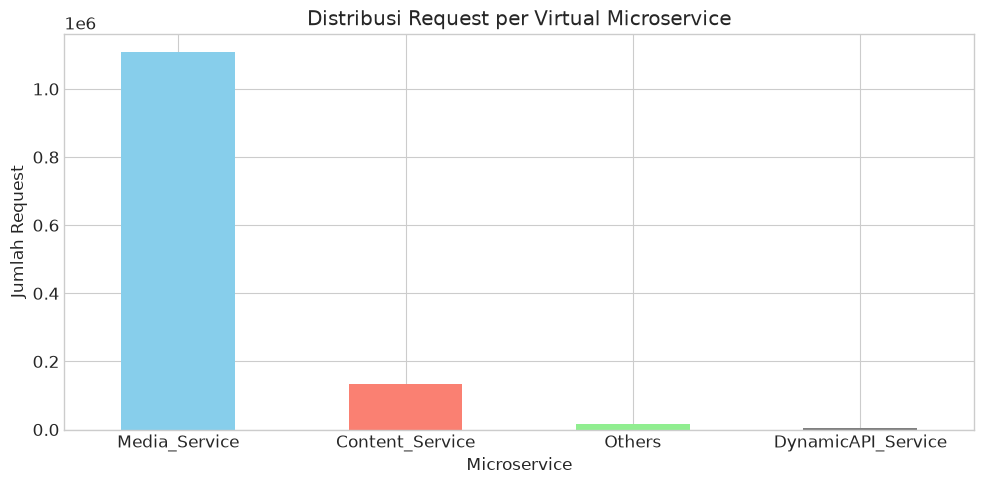

In [5]:
# Plot pembagian request per-layanan
service_counts = df['service'].value_counts()
plt.figure(figsize=(10, 5))
service_counts.plot(kind='bar', color=['skyblue', 'salmon', 'lightgreen', 'grey'])
plt.title('Distribusi Request per Virtual Microservice')
plt.xlabel('Microservice')
plt.ylabel('Jumlah Request')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [6]:
# Resample ke 1 detik untuk menghitung total RPS
print("Menghitung total RPS per detik...")
total_rps = df.resample('1s').size()

# Hitung RPS untuk masing-masing virtual microservice
print("Menghitung RPS per-layanan...")
services = df['service'].cat.categories
rps_services = {}

for svc in services:
    svc_df = df[df['service'] == svc]
    rps_services[svc] = svc_df.resample('1s').size().reindex(total_rps.index, fill_value=0)

# Gabungkan ke satu DataFrame
rps_df = pd.DataFrame(rps_services)
rps_df['total_rps'] = total_rps
rps_df.head()


Menghitung total RPS per detik...
Menghitung RPS per-layanan...


,Content_Service,DynamicAPI_Service,Media_Service,Others,total_rps
datetime,,,,,
1998-05-04 00:00:02,0,0,3,0,3
1998-05-04 00:00:03,1,0,1,0,2
1998-05-04 00:00:04,5,0,5,0,10
1998-05-04 00:00:05,4,0,19,0,23
1998-05-04 00:00:06,1,0,11,0,12


In [7]:
# Statistik Deskriptif RPS
stats = rps_df.describe()
print("Statistik Deskriptif RPS per-detik:")
print(stats.loc[['min', 'mean', 'max']])


Statistik Deskriptif RPS per-detik:
      Content_Service  DynamicAPI_Service  Media_Service    Others  total_rps
min          0.000000            0.000000       0.000000  0.000000   0.000000
mean         1.545072            0.054331      12.818429  0.196433  14.614265
max         16.000000           10.000000      64.000000  5.000000  71.000000


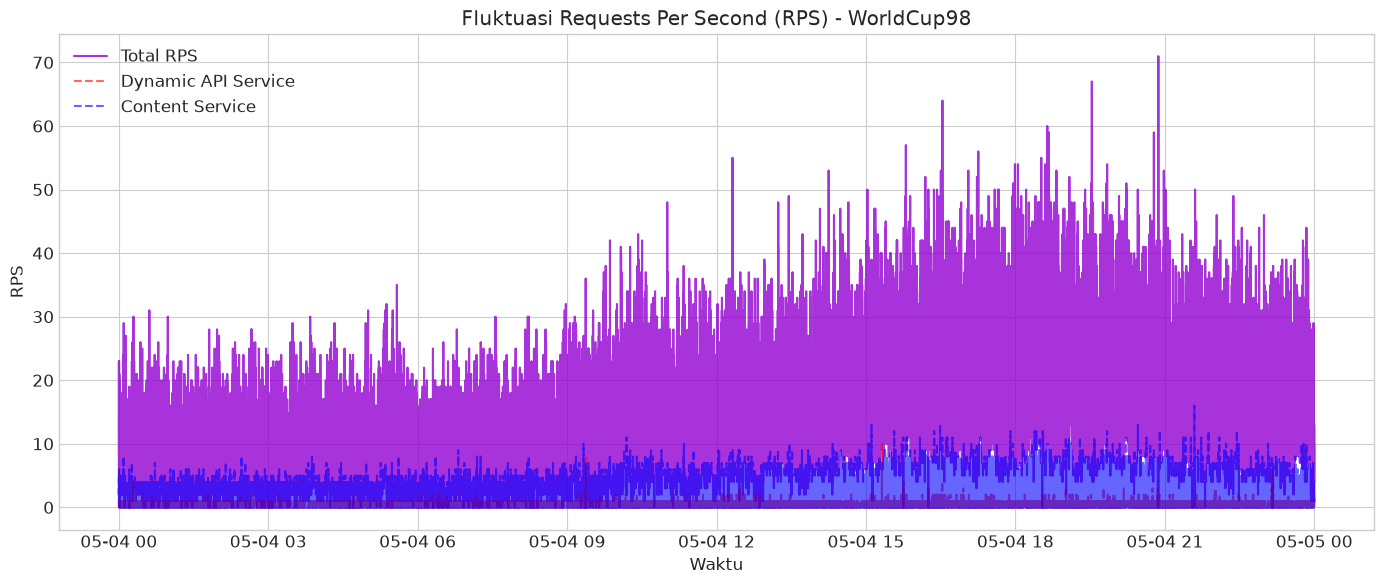

In [8]:
# Plot runtun waktu total RPS
plt.figure(figsize=(14, 6))
plt.plot(rps_df.index, rps_df['total_rps'], label='Total RPS', color='darkviolet', alpha=0.8)
plt.plot(rps_df.index, rps_df['DynamicAPI_Service'], label='Dynamic API Service', color='red', alpha=0.6, linestyle='--')
plt.plot(rps_df.index, rps_df['Content_Service'], label='Content Service', color='blue', alpha=0.6, linestyle='--')

plt.title('Fluktuasi Requests Per Second (RPS) - WorldCup98')
plt.xlabel('Waktu')
plt.ylabel('RPS')
plt.legend()
plt.tight_layout()
plt.show()


Trafik puncak terjadi pada: 1998-05-04 20:52:11 dengan 71 RPS


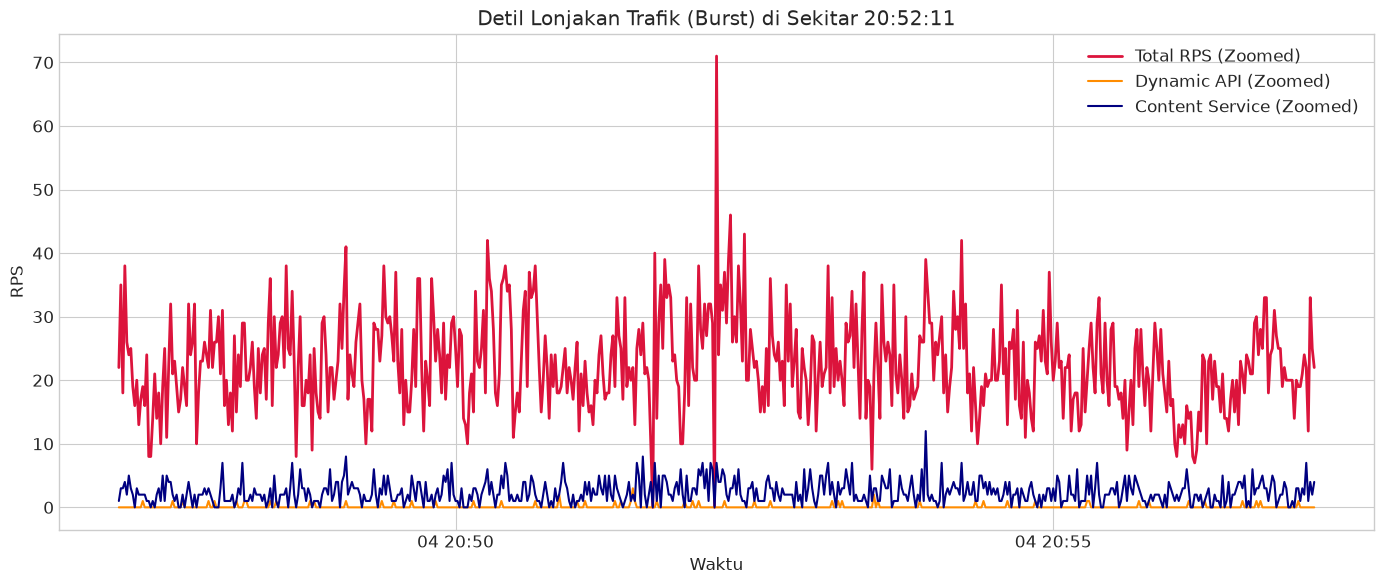

In [9]:
# Deteksi waktu trafik puncak (peak)
peak_time = rps_df['total_rps'].idxmax()
print(f"Trafik puncak terjadi pada: {peak_time} dengan {rps_df['total_rps'].max()} RPS")

# Zoom +/- 5 menit sekitar peak
zoom_start = peak_time - pd.Timedelta(minutes=5)
zoom_end = peak_time + pd.Timedelta(minutes=5)
zoomed_df = rps_df.loc[zoom_start:zoom_end]

plt.figure(figsize=(14, 6))
plt.plot(zoomed_df.index, zoomed_df['total_rps'], label='Total RPS (Zoomed)', color='crimson', linewidth=2)
plt.plot(zoomed_df.index, zoomed_df['DynamicAPI_Service'], label='Dynamic API (Zoomed)', color='darkorange')
plt.plot(zoomed_df.index, zoomed_df['Content_Service'], label='Content Service (Zoomed)', color='navy')

plt.title(f'Detil Lonjakan Trafik (Burst) di Sekitar {peak_time:%H:%M:%S}')
plt.xlabel('Waktu')
plt.ylabel('RPS')
plt.legend()
plt.tight_layout()
plt.show()


In [10]:
# Simpan hasil agregasi per-detik ke CSV
output_csv_path = 'dataset/aggregated_worldcup98_rps.csv'
rps_df.to_csv(output_csv_path)
print(f"Dataset hasil agregasi per-detik berhasil disimpan ke: {output_csv_path}")


Dataset hasil agregasi per-detik berhasil disimpan ke: dataset/aggregated_worldcup98_rps.csv


## Kesimpulan Skenario Autoscaling
Dataset **WorldCup98 (TR2)** memperlihatkan fluktuasi trafik yang sangat nyata dan dinamis dengan lonjakan mendadak (*burst/spike*). Hal ini membuat model proaktif auto-scaling berbasis LSTM/GRU dapat diuji secara objektif dalam memprediksi lonjakan trafik yang ekstrem.